In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, RocCurveDisplay

qda = QuadraticDiscriminantAnalysis()

df = pd.read_csv('Dados completos.csv',sep=';')
df = df.drop(columns=['Unnamed: 7','Unnamed: 8'])

colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.replace('.', '', regex=False).astype(float)

0.6833333333333333


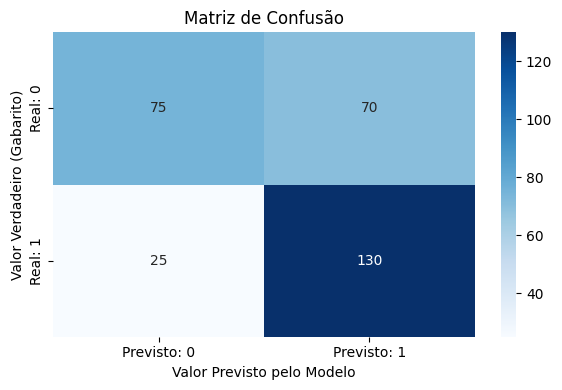

In [6]:
X = df['Skewness'].reset_index()
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=0)

qda.fit(X_train,Y_train)

Y_predict = qda.predict(X_test)

print(accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


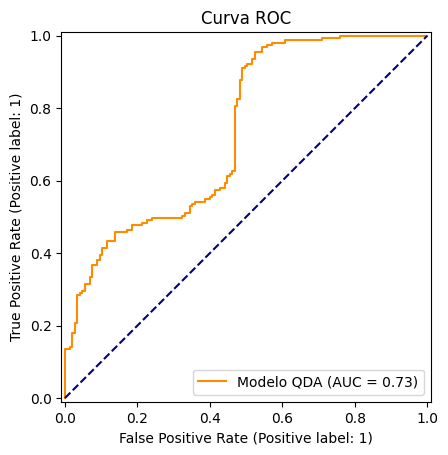

In [7]:
RocCurveDisplay.from_estimator(
    qda, 
    X_test, 
    Y_test, 
    name="Modelo QDA",
    color="darkorange"
)

plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.title("Curva ROC")
plt.show()